EX 6_05

Prima di tutto : conda activate acc-env, pip install corrfunc

In [21]:
import numpy as np 
import matplotlib.pyplot as plt
import Corrfunc

In [22]:
#generate a random sample of points
box_size = 1000
n_points = 50000
volume=box_size**3
density = n_points/volume
print("Density particles per Mpc/h^3: ", density)

Density particles per Mpc/h^3:  5e-05


In [23]:
X,Y, Z = np.random.rand(3, n_points) * box_size

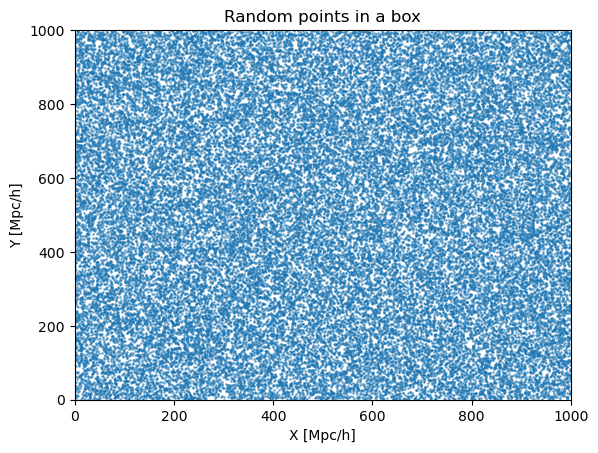

In [24]:
plt.plot(X,Y, 'o', markersize=1, alpha=0.5)
plt.xlim(0, box_size)
plt.ylim(0, box_size)
plt.xlabel('X [Mpc/h]')
plt.ylabel('Y [Mpc/h]')
plt.title('Random points in a box')
plt.show()

il catalogo è gia pronto

In [25]:
#compute RR pairs
r_min=0
r_max=20
n_bins=20
bin_edges=np.linspace(r_min, r_max, n_bins+1)

In [26]:
#compute pairs
RR=Corrfunc.theory.DD(
    autocorr=True,
    nthreads=4,
    binfile=bin_edges,
    X1=X,
    Y1=Y,
    Z1=Z,
    boxsize=box_size,
    periodic=True
    #periodic=False
    )


In [27]:
RR  #è ordered array=è un array con una serie di info ordinate e ha le coppie

array([( 0.,  1., 0., 50010, 0.), ( 1.,  2., 0.,    58, 0.),
       ( 2.,  3., 0.,   196, 0.), ( 3.,  4., 0.,   418, 0.),
       ( 4.,  5., 0.,   662, 0.), ( 5.,  6., 0.,   884, 0.),
       ( 6.,  7., 0.,  1280, 0.), ( 7.,  8., 0.,  1698, 0.),
       ( 8.,  9., 0.,  2300, 0.), ( 9., 10., 0.,  2844, 0.),
       (10., 11., 0.,  3450, 0.), (11., 12., 0.,  4160, 0.),
       (12., 13., 0.,  4910, 0.), (13., 14., 0.,  5782, 0.),
       (14., 15., 0.,  6378, 0.), (15., 16., 0.,  7580, 0.),
       (16., 17., 0.,  8456, 0.), (17., 18., 0.,  9542, 0.),
       (18., 19., 0., 10730, 0.), (19., 20., 0., 12268, 0.)],
      dtype=[('rmin', '<f8'), ('rmax', '<f8'), ('ravg', '<f8'), ('npairs', '<u8'), ('weightavg', '<f8')])

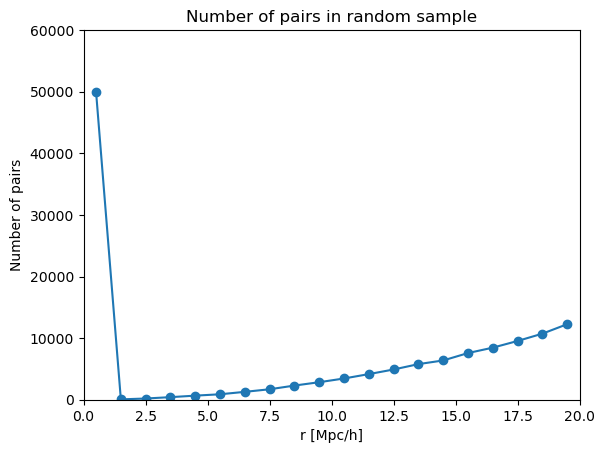

In [28]:
bin_centers=0.5*(bin_edges[1:]+bin_edges[:-1])
plt.plot(bin_centers, RR['npairs'], 'o-')
plt.xlabel('r [Mpc/h]')
plt.ylabel('Number of pairs')
plt.title('Number of pairs in random sample')
plt.xlim(r_min, r_max)
plt.ylim(0, 1.2*RR['npairs'].max())
plt.show()

nel primo bin a 0 c'è un sacco di coppie!!! 50010=num oggetti+num coppie in quel bin , quindi è segnale di correlazione più segnale a 0

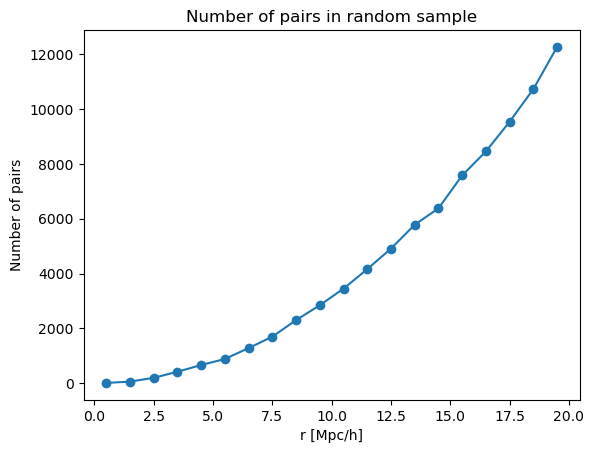

In [29]:
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
RR['npairs'] [0]-=n_points
plt.plot(bin_centers, RR['npairs'], 'o-')
plt.xlabel('r [Mpc/h]')
plt.ylabel('Number of pairs')
plt.title('Number of pairs in random sample')
#plt.xlim(r_min, r_max)
#plt.ylim(0, 1.2*RR['npairs'].max())
plt.show()

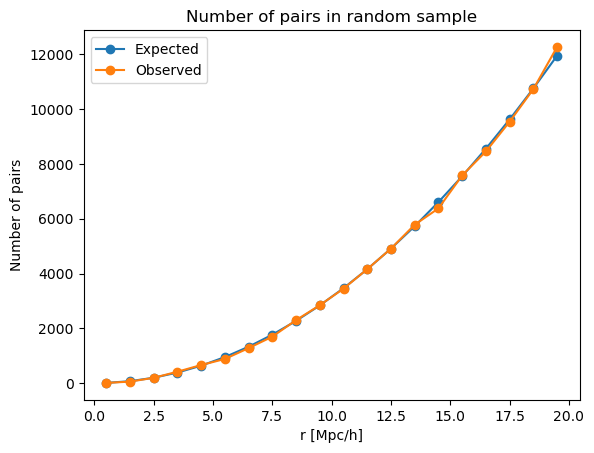

In [30]:
#pairs_per_objet=density*4/3*np.pi*(bin_centers**3-bin_edges[:-1]**3)#num medio di oggetti random attorno a oggetto mio
pairs_per_object = density * (4/3) * np.pi * (bin_edges[1:]**3 - bin_edges[:-1]**3)
expected_pairs =  n_points * pairs_per_object
plt.plot(bin_centers, expected_pairs, 'o-', label='Expected')#expected
plt.plot(bin_centers, RR['npairs'] , 'o-', label='Observed')#observed
plt.xlabel('r [Mpc/h]')
plt.ylabel('Number of pairs')
plt.title('Number of pairs in random sample')
#plt.xlim(r_min, r_max)
#plt.ylim(0, 1.2*RR['npairs'].max())
plt.legend()
plt.show()

se metto periodic false--> expected conta più coppie che nella realtà, non sto considerando l'ipotesi di volume finito (lo ha il modello, non le coppie): mi perdo un numero di coppie che aumneta man mano che distanza aumenta